# Importing Libraries And Setting Up

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import re
import string

from collections import Counter
from tqdm import tqdm

import nltk
nltk.download('punkt_tab')

# Install Indic NLP Library
!pip install indic-nlp-library

# Import Indic NLP components
from indicnlp import common
from indicnlp.tokenize import indic_tokenize
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.8 MB/s eta 0:00:00


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Utility Functions

In [3]:
# Initialize normalizers for Indian languages
factory = IndicNormalizerFactory()
hi_normalizer = factory.get_normalizer("hi", remove_nuktas=False)
bn_normalizer = factory.get_normalizer("bn", remove_nuktas=False)

def preprocess_english(sentences):
    """Preprocess English sentences"""
    tokenized_sentences = []
    for sentence in sentences:
        # Remove punctuation but keep basic structure
        sentence = ''.join([char for char in sentence if char not in string.punctuation or char in ['.', '!', '?']])
        # Tokenize with nltk
        tokens = nltk.word_tokenize(sentence.lower())
        tokenized_sentences.append(tokens)
    return tokenized_sentences

def preprocess_hindi(sentences):
    """Preprocess Hindi sentences using Indic NLP"""
    tokenized_sentences = []
    for sentence in sentences:
        # Normalize Hindi text
        normalized_sentence = hi_normalizer.normalize(sentence)
        # Tokenize using Indic NLP
        tokens = indic_tokenize.trivial_tokenize(normalized_sentence)
        tokenized_sentences.append(tokens)
    return tokenized_sentences

def preprocess_bengali(sentences):
    """Preprocess Bengali sentences using Indic NLP"""
    tokenized_sentences = []
    for sentence in sentences:
        # Normalize Bengali text
        normalized_sentence = bn_normalizer.normalize(sentence)
        # Tokenize using Indic NLP
        tokens = indic_tokenize.trivial_tokenize(normalized_sentence)
        tokenized_sentences.append(tokens)
    return tokenized_sentences

In [4]:
def encode_and_pad(vocab, sent, max_length):
    sos = [vocab["<SOS>"]]
    eos = [vocab["<EOS>"]]
    pad = [vocab["<PAD>"]]

    if len(sent) < max_length - 2: # -2 for SOS and EOS
        n_pads = max_length - 2 - len(sent)
        encoded = [vocab[w] for w in sent]
        return sos + encoded + eos + pad * n_pads
    else: # sent is longer than max_length; truncating
        encoded = [vocab[w] for w in sent]
        truncated = encoded[:max_length - 2]
        return sos + truncated + eos

# Encoder - Decoder Architechture

In [5]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        # Embedding layer
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=0)

        # GRU layer. The input and output are both of the same size
        #  since embedding size = hidden size in this example
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

    def forward(self, input, hidden):
        # The inputs are first transformed into embeddings
        embedded = self.embedding(input)
        output = embedded

        # As in any RNN, the new input and the previous hidden states are fed
        #  into the model at each time step
        output, hidden = self.gru(output, hidden)
        return output, hidden

    def initHidden(self):
        # This method is used to create the innitial hidden states for the encoder
        return torch.zeros(1, batch_size, self.hidden_size)

In [6]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size

        # Embedding layer
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=0)

        # The GRU layer
        self.gru = nn.GRU(hidden_size, hidden_size)

        # Fully-connected layer for scores
        self.out = nn.Linear(hidden_size, output_size)

        # Applying Softmax to the scores
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        # Feeding input through embedding layer
        output = self.embedding(input)

        # Applying an activation function (ReLu)
        output = F.relu(output)

        # Feeding input and previous hidden state
        output, hidden = self.gru(output, hidden)

        # Outputting scores from the final time-step
        output = self.softmax(self.out(output[0]))

        return output, hidden

    # We do not need an .initHidden() method for the decoder since the encoder output will act as input in the first decoder time-step

# English To Bengali

In [7]:
with open('/kaggle/input/cs779-capstone-project/train_data1.json', 'r') as file: # Replace this path with the dataset path in your local machine
    data = json.load(file)

In [8]:
# Process JSON data
source_sentences_train = []
target_sentences_train = []

source_sentences_val = []
target_sentences_val = []

id_train = []
id_val = []

In [9]:
for language_pair, language_data in data.items():
  print(f"Language Pair: {language_pair}")


Language Pair: English-Bengali
Language Pair: English-Hindi


In [10]:
for language_pair, language_data in data.items():
    if(language_pair == "English-Bengali"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                target_sentences_val.append(target)
                id_val.append(entry_id)
              else:
                source_sentences_train.append(source)
                target_sentences_train.append(target)
                id_train.append(entry_id)

Language Pair: English-Bengali
  Data Type: Train


In [11]:
with open('/kaggle/input/cs779-capstone-project/val_data1.json', 'r') as file: # Replace this path with the dataset path in your local machine
    data = json.load(file)

In [12]:
for language_pair, language_data in data.items():
    if(language_pair == "English-Bengali"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              #target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                #target_sentences_val.append(target)
                id_val.append(entry_id)
              else:
                source_sentences_train.append(source)
                #target_sentences_train.append(target)
                id_train.append(entry_id)

Language Pair: English-Bengali
  Data Type: Validation


In [13]:
print(len(source_sentences_train))
print(len(target_sentences_train))

print(len(source_sentences_val))
print(len(target_sentences_val))

68849
68849
9836
0


In [14]:
df=pd.DataFrame({'English':source_sentences_train,'Bengali':target_sentences_train})
df

,English,Bengali
0,Do not forget to visit the point where the Nar...,এই জায়গাগুলো দেখতে ভুলো না যেখানে নর্মদা নদী ম...
1,It is evident that the biggest cause of povert...,এই কথা স্পষ্ট যে দরিদ্রতার বড় কারণ হল অশিক্ষা ।
2,The film was released theatrically on 12 April...,চলচ্চিত্রটি ২০১৩ সালের ১২ই এপ্রিল প্রেক্ষাগৃহে...
3,is wyatt's birthday party at ten p. m.,অনিমেষ এর জন্মদিনের পার্টি রাত দশটায়
4,"Apart from being used as an eatable, barley is...",খাদ্যদ্রব্য ছাড়াও যব আরো বিভিন্ন ক্ষেত্রে যেমন...
...,...,...
68844,But it is evident that there is change in both...,তাও এটা প্রত্যক্ষভাবে দেখা যায় যে প্রিন্ট মিড...
68845,Include a detailed listing of all of your prod...,ছবি সহ সম্পূর্ণ করা আপনার সমস্ত পণ্যের একটি বি...
68846,"Each subcategory counts as one page, pages in ...",প্রতিটি উপবিভাগ একটি পৃষ্ঠা হিসাবে গণনা করা হয...
68847,It is one of the country's oldest state-run pu...,এটি দেশের সবচেয়ে পুরনো রাষ্ট্র-চালিত সরকারী বা...


In [15]:
# target_sentences_train = [re.sub(r'[a-zA-Z]','',hi) for hi in target_sentences_train] #optional

In [16]:
english_tokens = preprocess_english(source_sentences_train)
english_test = preprocess_english(source_sentences_val)
bengali_tokens = preprocess_bengali(target_sentences_train)
bengali_test = preprocess_bengali(target_sentences_val)

In [17]:
en_train = english_tokens
en_test = english_test
de_train = bengali_tokens
de_test = bengali_test

In [18]:
en_index2word = ["<PAD>", "<SOS>", "<EOS>"]
de_index2word = ["<PAD>", "<SOS>", "<EOS>"]

for ds in [en_train, en_test]:
    for sent in ds:
        for token in sent:
            if token not in en_index2word:
                en_index2word.append(token)

for ds in [de_train, de_test]:
    for sent in ds:
        for token in sent:
            if token not in de_index2word:
                de_index2word.append(token)

In [19]:
en_index2word

['<PAD>',
 '<SOS>',
 '<EOS>',
 'do',
 'not',
 'forget',
 'to',
 'visit',
 'the',
 'point',
 'where',
 'narmada',
 'flowing',
 'through',
 'marble',
 'rocks',
 'interchanges',
 'its',
 'calmness',
 'and',
 'serenity',
 'into',
 'insouciance',
 '.',
 'it',
 'is',
 'evident',
 'that',
 'biggest',
 'cause',
 'of',
 'poverty',
 'illiteracy',
 'film',
 'was',
 'released',
 'theatrically',
 'on',
 '12',
 'april',
 '2013',
 'wyatts',
 'birthday',
 'party',
 'at',
 'ten',
 'p.',
 'm',
 'apart',
 'from',
 'being',
 'used',
 'as',
 'an',
 'eatable',
 'barley',
 'also',
 'in',
 'many',
 'other',
 'fields',
 'like',
 'industries',
 'agriculture',
 'emperor',
 'akbar',
 'got',
 'state',
 'museum',
 'constructed',
 'during',
 'his',
 'trip',
 'ajmer',
 'initiate',
 'music',
 'electronic',
 'playlist',
 'srinagar',
 'a',
 'distance',
 '305',
 'kms',
 'jammu',
 'devotee',
 'chosen',
 'karaga',
 'or',
 'clay',
 'pot',
 'placed',
 'head',
 'city',
 'lined',
 'up',
 'with',
 'shops',
 'have',
 'everything

In [20]:
en_word2index = {token: idx for idx, token in enumerate(en_index2word)}
de_word2index = {token: idx for idx, token in enumerate(de_index2word)}

In [21]:
len(en_word2index)

61670

In [22]:
en_lengths = sum([len(sent) for sent in en_train])/len(en_train)
de_lengths = sum([len(sent) for sent in de_train])/len(de_train)

In [23]:
seq_length = 20

In [24]:
en_train_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_train]
en_test_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_test]
de_train_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_train]
de_test_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_test]

In [25]:
en_train_encoded[1]

[1, 24, 25, 26, 27, 8, 28, 29, 30, 31, 25, 32, 23, 2, 0, 0, 0, 0, 0, 0]

In [26]:
batch_size = 50

train_x = np.array(en_train_encoded)
train_y = np.array(de_train_encoded)
test_x = np.array(en_test_encoded)
test_y = np.array(de_test_encoded)

train_ds = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
test_ds = TensorDataset(torch.from_numpy(test_x))


train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size, drop_last=True)
#test_dl = DataLoader(test_ds, shuffle=True, batch_size=batch_size, drop_last=True)

In [27]:
train_x[1]

array([ 1, 24, 25, 26, 27,  8, 28, 29, 30, 31, 25, 32, 23,  2,  0,  0,  0,
        0,  0,  0])

In [28]:
train_ds[1]

(tensor([ 1, 24, 25, 26, 27,  8, 28, 29, 30, 31, 25, 32, 23,  2,  0,  0,  0,  0,
          0,  0]),
 tensor([ 1,  3, 27, 28, 29, 30, 31, 32, 33, 34, 26,  2,  0,  0,  0,  0,  0,  0,
          0,  0]))

In [29]:
hidden_size = 128

In [30]:
seq_length = 20

In [31]:
encoder = EncoderRNN(len(en_index2word), hidden_size).to(device)
encoder


EncoderRNN(
  (embedding): Embedding(61670, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True)
)

In [32]:
decoder = DecoderRNN(hidden_size, len(de_index2word)).to(device)
decoder

DecoderRNN(
  (embedding): Embedding(93511, 128, padding_idx=0)
  (gru): GRU(128, 128)
  (out): Linear(in_features=128, out_features=93511, bias=True)
  (softmax): LogSoftmax(dim=1)
)

In [33]:
criterion = nn.NLLLoss()
enc_optimizer = torch.optim.Adam(encoder.parameters(), lr = 3e-3)
dec_optimizer = torch.optim.Adam(decoder.parameters(), lr = 3e-3)

In [34]:
losses = []

In [35]:
input_length = target_length = seq_length

SOS = en_word2index["<SOS>"]
EOS = en_word2index["<EOS>"]

epochs = 1

for epoch in range(epochs):
    for idx, batch in enumerate(train_dl):

        # Creating initial hidden states for the encoder
        encoder_hidden = encoder.initHidden()

        # Sending to device
        encoder_hidden = encoder_hidden.to(device)

        # Assigning the input and sending to device
        input_tensor = batch[0].to(device)

        # Assigning the output and sending to device
        target_tensor = batch[1].to(device)


        # Clearing gradients
        enc_optimizer.zero_grad()
        dec_optimizer.zero_grad()

        # Enabling gradient calculation
        with torch.set_grad_enabled(True):

            # Feeding batch into encoder
            encoder_output, encoder_hidden = encoder(input_tensor, encoder_hidden)

            # This is a placeholder tensor for decoder outputs. We send it to device as well
            dec_result = torch.zeros(target_length, batch_size, len(de_index2word)).to(device)

            # Creating a batch of SOS tokens which will all be fed to the decoder
            decoder_input = target_tensor[:, 0].unsqueeze(dim=0).to(device)

            # Creating initial hidden states of the decoder by copying encoder hidden states
            decoder_hidden = encoder_hidden

            # For each time-step in decoding:
            for i in range(1, target_length):

                # Feed input and previous hidden states
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)

                # Finding the best scoring word
                best = decoder_output.argmax(1)

                # Assigning next input as current best word
                decoder_input = best.unsqueeze(dim=0)

                # Creating an entry in the placeholder output tensor
                dec_result[i] = decoder_output


            # Creating scores and targets for loss calculation
            scores = dec_result.transpose(1, 0)[1:].reshape(-1, dec_result.shape[2])
            targets = target_tensor[1:].reshape(-1)

            # Calculating loss
            loss = criterion(scores, targets)

            # Performing backprop and clipping excess gradients
            loss.backward()

            torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1)
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1)

            enc_optimizer.step()
            dec_optimizer.step()

            # Keeping track of loss
            losses.append(loss.item())
            if idx % 100 == 0:
                print(idx, sum(losses)/len(losses))

0 10.860014915466309
100 6.689273083564078
200 6.318590975519436
300 6.18342605381709
400 6.078409823990819
500 6.01527990314537
600 5.952564194277796
700 5.911337687863773
800 5.871865666016806
900 5.839944241446475
1000 5.810924584334428
1100 5.781865231239395
1200 5.757818040204584
1300 5.732646337387472


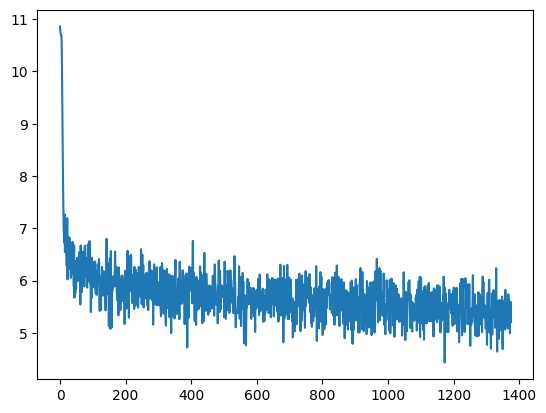

In [36]:
plt.plot(losses)

In [37]:
val_ids = [ i for i,_ in data["English-Bengali"]["Validation"].items()]

In [38]:
val_outs = []
for i in tqdm(range(len(test_ds))):
  encoder_hidden = torch.zeros(1, 1, hidden_size).to(device)
  input_tensor = test_ds[i][0].unsqueeze(dim=0).to(device)
  result = []
  with torch.set_grad_enabled(False):
    encoder_output, encoder_hidden = encoder(input_tensor, encoder_hidden)
    decoder_input = torch.tensor([SOS]).unsqueeze(dim=0).to(device)
    decoder_hidden = encoder_hidden
    for di in range(1, target_length):
        decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        best = decoder_output.argmax(1)
        result.append(de_index2word[best.to('cpu').item()])
        if best.item() == EOS:
            break

        decoder_input = best.unsqueeze(dim=0)
  result = [i for i in result if not i in ['<EOS>', '<PAD>', '<SOS>']]
  val_outs.append(" ".join(result))

100%|██████████| 9836/9836 [01:15<00:00, 130.24it/s]


In [39]:
df0 = pd.DataFrame()
df0["ID"] = val_ids
df0["Translation"] = val_outs

In [40]:
df0.to_csv('answersB.csv', index = False)

In [41]:
pd.read_csv("/kaggle/working/answersB.csv")

,ID,Translation
0,147532,"এই থেকে থেকে থেকে , থেকে , , থেকে , থেকে , থেকে"
1,147533,"এই , এবং এবং এবং এবং এবং এবং এবং এবং এবং এবং এ..."
2,147534,"উদাহরণস্বরূপ , জন্য জন্য জন্য , জন্য জন্য , জন..."
3,147535,"রাজ্যের সালে রাজ্যের সালে রাজ্যের , ছিল ছিল । ।"
4,147536,"ভারতের ভারতের ভারতের ভারতের , ভারতের , এবং এবং..."
...,...,...
9831,157363,এই প্রথম প্রথম প্রথম প্রথম প্রথম প্রথম প্রথম ।
9832,157364,এখানে এখানে এখানে এখানে । । ।
9833,157365,একটি একটি একটি একটি
9834,157366,এই এবং এবং এবং এবং এবং । । ।


# English To Hindi

In [42]:
with open('/kaggle/input/cs779-capstone-project/train_data1.json', 'r') as file: # Replace this path with the dataset path in your local machine
    data = json.load(file)

In [43]:
# Process JSON data
source_sentences_train = []
target_sentences_train = []

source_sentences_val = []
target_sentences_val = []

id_train = []
id_val = []

In [44]:
for language_pair, language_data in data.items():
  print(f"Language Pair: {language_pair}")


Language Pair: English-Bengali
Language Pair: English-Hindi


In [45]:
for language_pair, language_data in data.items():
    if(language_pair == "English-Hindi"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                target_sentences_val.append(target)
                id_val.append(entry_id)
              else:
                source_sentences_train.append(source)
                target_sentences_train.append(target)
                id_train.append(entry_id)

Language Pair: English-Hindi
  Data Type: Train


In [46]:
with open('/kaggle/input/cs779-capstone-project/val_data1.json', 'r') as file: # Replace this path with the dataset path in your local machine
    data = json.load(file)

In [47]:
for language_pair, language_data in data.items():
    if(language_pair == "English-Hindi"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              #target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                #target_sentences_val.append(target)
                id_val.append(entry_id)
              else:
                source_sentences_train.append(source)
                #target_sentences_train.append(target)
                id_train.append(entry_id)

Language Pair: English-Hindi
  Data Type: Validation


In [48]:
print(len(source_sentences_train))
print(len(target_sentences_train))

print(len(source_sentences_val))
print(len(target_sentences_val))

80797
80797
11543
0


In [49]:
df=pd.DataFrame({'English':source_sentences_train,'Hindi':target_sentences_train})
df

,English,Hindi
0,cancel everything on my calendar,मेरे कैलेंडर पर सब कुछ रद्द करें
1,Adrenal hormone levels are at their peak durin...,अधिवृक्क के हार्मोन का स्तर प्रातःकाल में अपने...
2,"Golden threads are obtained from Surat, the qu...","स्वर्ण धागे सूरत से प्राप्त होते हैं, जिनकी गु..."
3,Look for agglutination within 30 seconds.,30 सेकेण्ड के भीतर एग्लूटिनेशन देखें।
4,The non-pompousness and informality of their l...,उनके जीवन की आडंबरहीनता एवं अनौपचारिकता उनके स...
...,...,...
80792,"So, is it that this is the optimization proble...","तो, यह अनुकूलन समस्या है जिसमें हम रुचि रखते थे।"
80793,In this Masjid made with red stones there are ...,लाल पत्थरों से बनायी गयी इस मस्जिद में हिन्दू ...
80794,"He began to work on the movie on August 17, 20...","उन्होंने 17 अगस्त, 2010 को फिल्म पर काम करना श..."
80795,start a new shopping list,एक नई खरीदारी सूची शुरू करें


In [50]:
# target_sentences_train = [re.sub(r'[a-zA-Z]','',hi) for hi in target_sentences_train] #optional

In [51]:
english_tokens = preprocess_english(source_sentences_train)
english_test = preprocess_english(source_sentences_val)
hindi_tokens = preprocess_hindi(target_sentences_train)
hindi_test = preprocess_hindi(target_sentences_val)

In [52]:
en_train = english_tokens
en_test = english_test
de_train = hindi_tokens
de_test = hindi_test

In [53]:
en_index2word = ["<PAD>", "<SOS>", "<EOS>"]
de_index2word = ["<PAD>", "<SOS>", "<EOS>"]

for ds in [en_train, en_test]:
    for sent in ds:
        for token in sent:
            if token not in en_index2word:
                en_index2word.append(token)

for ds in [de_train, de_test]:
    for sent in ds:
        for token in sent:
            if token not in de_index2word:
                de_index2word.append(token)

In [54]:
en_index2word

['<PAD>',
 '<SOS>',
 '<EOS>',
 'cancel',
 'everything',
 'on',
 'my',
 'calendar',
 'adrenal',
 'hormone',
 'levels',
 'are',
 'at',
 'their',
 'peak',
 'during',
 'the',
 'morning',
 'and',
 'taper',
 'off',
 'evening',
 'reaching',
 'a',
 'low',
 'level',
 'around',
 '3',
 'am',
 'an',
 'important',
 'function',
 'of',
 'these',
 'hormones',
 'is',
 'to',
 'regulate',
 'vascular',
 'muscle',
 'tone',
 'prevent',
 'vasocodilation',
 '.',
 'golden',
 'threads',
 'obtained',
 'from',
 'surat',
 'quality',
 'being',
 '1200',
 'yards',
 '1080',
 'meters',
 'per',
 'tola',
 '11.664',
 'grams',
 'look',
 'for',
 'agglutination',
 'within',
 '30',
 'seconds',
 'nonpompousness',
 'informality',
 'life',
 'reflected',
 'in',
 'literature',
 'also',
 'world',
 'chess',
 'championship',
 '2006',
 'which',
 'kramnik',
 'beat',
 'fide',
 'champion',
 'veselin',
 'topalov',
 'reunified',
 'titles',
 'made',
 'undisputed',
 'heavily',
 'embroidered',
 'rugs',
 'shawls',
 'produced',
 'gujarat',
 '’'

In [55]:
en_word2index = {token: idx for idx, token in enumerate(en_index2word)}
de_word2index = {token: idx for idx, token in enumerate(de_index2word)}

In [56]:
len(en_word2index)

66061

In [57]:
en_lengths = sum([len(sent) for sent in en_train])/len(en_train)
de_lengths = sum([len(sent) for sent in de_train])/len(de_train)

In [58]:
seq_length = 20

In [59]:
en_train_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_train]
en_test_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_test]
de_train_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_train]
de_test_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_test]

In [60]:
en_train_encoded[1]

[1, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 15, 16, 21, 22, 23, 2]

In [61]:
batch_size = 50

train_x = np.array(en_train_encoded)
train_y = np.array(de_train_encoded)
test_x = np.array(en_test_encoded)
test_y = np.array(de_test_encoded)

train_ds = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
test_ds = TensorDataset(torch.from_numpy(test_x))


train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size, drop_last=True)
#test_dl = DataLoader(test_ds, shuffle=True, batch_size=batch_size, drop_last=True)

In [62]:
train_x[1]

array([ 1,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 15, 16, 21,
       22, 23,  2])

In [63]:
train_ds[1]

(tensor([ 1,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 15, 16, 21, 22,
         23,  2]),
 tensor([ 1, 10, 11, 12, 13, 14, 15, 16, 17, 18,  5, 19, 20, 21, 22, 23, 24, 25,
         26,  2]))

In [64]:
hidden_size = 128

In [65]:
seq_length = 20

In [66]:
encoder = EncoderRNN(len(en_index2word), hidden_size).to(device)
encoder


EncoderRNN(
  (embedding): Embedding(66061, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True)
)

In [67]:
decoder = DecoderRNN(hidden_size, len(de_index2word)).to(device)
decoder

DecoderRNN(
  (embedding): Embedding(72586, 128, padding_idx=0)
  (gru): GRU(128, 128)
  (out): Linear(in_features=128, out_features=72586, bias=True)
  (softmax): LogSoftmax(dim=1)
)

In [68]:
criterion = nn.NLLLoss()
enc_optimizer = torch.optim.Adam(encoder.parameters(), lr = 3e-3)
dec_optimizer = torch.optim.Adam(decoder.parameters(), lr = 3e-3)

In [69]:
losses = []

In [70]:
input_length = target_length = seq_length

SOS = en_word2index["<SOS>"]
EOS = en_word2index["<EOS>"]

epochs = 1

for epoch in range(epochs):
    for idx, batch in enumerate(train_dl):

        # Creating initial hidden states for the encoder
        encoder_hidden = encoder.initHidden()

        # Sending to device
        encoder_hidden = encoder_hidden.to(device)

        # Assigning the input and sending to device
        input_tensor = batch[0].to(device)

        # Assigning the output and sending to device
        target_tensor = batch[1].to(device)


        # Clearing gradients
        enc_optimizer.zero_grad()
        dec_optimizer.zero_grad()

        # Enabling gradient calculation
        with torch.set_grad_enabled(True):

            # Feeding batch into encoder
            encoder_output, encoder_hidden = encoder(input_tensor, encoder_hidden)

            # This is a placeholder tensor for decoder outputs. We send it to device as well
            dec_result = torch.zeros(target_length, batch_size, len(de_index2word)).to(device)

            # Creating a batch of SOS tokens which will all be fed to the decoder
            decoder_input = target_tensor[:, 0].unsqueeze(dim=0).to(device)

            # Creating initial hidden states of the decoder by copying encoder hidden states
            decoder_hidden = encoder_hidden

            # For each time-step in decoding:
            for i in range(1, target_length):

                # Feed input and previous hidden states
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)

                # Finding the best scoring word
                best = decoder_output.argmax(1)

                # Assigning next input as current best word
                decoder_input = best.unsqueeze(dim=0)

                # Creating an entry in the placeholder output tensor
                dec_result[i] = decoder_output


            # Creating scores and targets for loss calculation
            scores = dec_result.transpose(1, 0)[1:].reshape(-1, dec_result.shape[2])
            targets = target_tensor[1:].reshape(-1)

            # Calculating loss
            loss = criterion(scores, targets)

            # Performing backprop and clipping excess gradients
            loss.backward()

            torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1)
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1)

            enc_optimizer.step()
            dec_optimizer.step()

            # Keeping track of loss
            losses.append(loss.item())
            if idx % 100 == 0:
                print(idx, sum(losses)/len(losses))

0 10.638401985168457
100 6.546412666245263
200 6.219024897807866
300 6.043500973140678
400 5.938238262832908
500 5.853480897739738
600 5.798641439682235
700 5.753684752677885
800 5.709515038203359
900 5.675151343350934
1000 5.641319658849146
1100 5.612569039783946
1200 5.588669223451892
1300 5.566632297202132
1400 5.5393215617820415
1500 5.517305717557212
1600 5.49573679613665


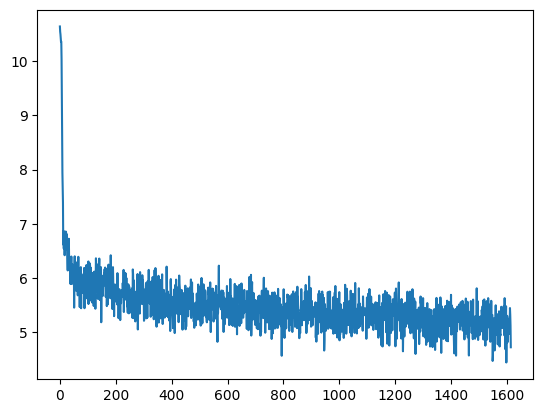

In [71]:
plt.plot(losses)

In [72]:
val_ids = [ i for i,_ in data["English-Hindi"]["Validation"].items()]

In [73]:
val_outs = []
for i in tqdm(range(len(test_ds))):
  encoder_hidden = torch.zeros(1, 1, hidden_size).to(device)
  input_tensor = test_ds[i][0].unsqueeze(dim=0).to(device)
  result = []
  with torch.set_grad_enabled(False):
    encoder_output, encoder_hidden = encoder(input_tensor, encoder_hidden)
    decoder_input = torch.tensor([SOS]).unsqueeze(dim=0).to(device)
    decoder_hidden = encoder_hidden
    for di in range(1, target_length):
        decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        best = decoder_output.argmax(1)
        result.append(de_index2word[best.to('cpu').item()])
        if best.item() == EOS:
            break

        decoder_input = best.unsqueeze(dim=0)
  result = [i for i in result if not i in ['<EOS>', '<PAD>', '<SOS>']]
  val_outs.append(" ".join(result))

100%|██████████| 11543/11543 [01:26<00:00, 132.94it/s]


In [74]:
df0 = pd.DataFrame()
df0["ID"] = val_ids
df0["Translation"] = val_outs

In [75]:
df0.to_csv('answersH.csv', index = False)

In [76]:
pd.read_csv("/kaggle/working/answersH.csv")

,ID,Translation
0,505511,क्या मेरे पर पर क्या पर क्या क्या क्या है
1,505512,और और और और और और । । ।
2,505513,"बाजरा : में में में में , है , , , है , है , है"
3,505514,इसके के के के के के के के के के के के लिए के लिए
4,505515,"राष्ट्रीय राष्ट्रीय उद्यान , , , , , , , , , ,..."
...,...,...
11538,517049,"उनके ने ने और और , और और , और और , और और और और और"
11539,517050,यह में में में में में में में है है है है है ...
11540,517051,मुझे में में में में में में में
11541,517052,हर में में में में में में में में में में में...


# Merge Both CSV Files into Final CSV File

In [77]:
df1 = pd.read_csv("/kaggle/working/answersB.csv") # Bengali
df2= pd.read_csv("/kaggle/working/answersH.csv")  # Hindi

In [78]:
df3 = pd.concat([df1, df2]) #Concat

In [79]:
df3

,ID,Translation
0,147532,"এই থেকে থেকে থেকে , থেকে , , থেকে , থেকে , থেকে"
1,147533,"এই , এবং এবং এবং এবং এবং এবং এবং এবং এবং এবং এ..."
2,147534,"উদাহরণস্বরূপ , জন্য জন্য জন্য , জন্য জন্য , জন..."
3,147535,"রাজ্যের সালে রাজ্যের সালে রাজ্যের , ছিল ছিল । ।"
4,147536,"ভারতের ভারতের ভারতের ভারতের , ভারতের , এবং এবং..."
...,...,...
11538,517049,"उनके ने ने और और , और और , और और , और और और और और"
11539,517050,यह में में में में में में में है है है है है ...
11540,517051,मुझे में में में में में में में
11541,517052,हर में में में में में में में में में में में...


In [80]:
df3.to_csv('answersBH.csv', index = False)

In [81]:
filtered_data = pd.read_csv("/kaggle/working/answersBH.csv")

In [82]:
answer = "/kaggle/working/answer.csv"
with open(answer, "w") as f:
  f.writelines("ID\tTranslation\n")
  for i in range(filtered_data.shape[0]):
    f.writelines(f'{filtered_data["ID"][i]}\t"{filtered_data["Translation"][i]}"\n')

### Make a zip file of answer.csv and save it as submission.zip and submit it